<a href="https://colab.research.google.com/github/boniphacebenja78-lgtm/LAB_PART_A-LAB_PART_B/blob/main/LAB_1_PART_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
from os import confstr
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches



In [51]:

# ===The Abstract Problem Interface===
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [52]:

# ===NODE CLASS===
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost


In [53]:

#===HELPER FUNCTION===
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])


In [54]:

# ===Implementing the Grid Serach Problem===
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1: Return True if state is equal to the goal state.
        return state == self.goal

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2: Return a list of legal action names
        legal_actions = []
        row, col = state
        for action_name, (dr,dc) in MOVES.items():
            neighbour = (row + dr, col + dc)

            # check the neigbour cell is in bounds ans is not an obstacle
            if self.in_bounds(neighbour) and self.is_free(neighbour):
              legal_actions.append(action_name)
        # return lega_actions
        return legal_actions

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:Return the next state after applying action to state.
        row, col = state
        dr, dc = MOVES[action]
        return (row + dr, col + dc)


    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:Return 1.
        return 1.0


In [55]:

#Self-Check for GridProblem
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")



GridProblem self-check passed.


In [56]:

# Sample Drone Map
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)


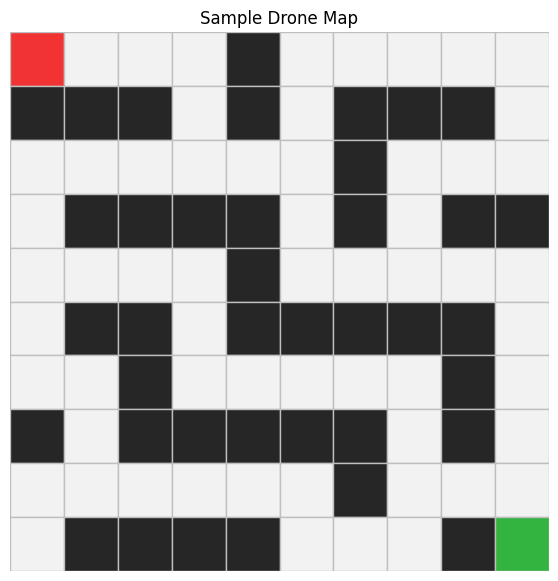

In [57]:

#===Visualization Helper===

def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()
plot_path(sample_grid, start, goal, title="Sample Drone Map")

In [58]:

#===The Shared expand Methods===

class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5: Implement the AIMA-style EXPAND(problem, node)
        s = node.state
        for action in problem.actions(s):
            s_prime = problem.result(s, action)
            cost = node.path_cost + problem.action_cost(s, action, s_prime)

            yield Node( state = s_prime,
                       parent = node,
                        action = action,
                        path_cost = cost)

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [59]:

# ===Breadth_First Search(BFS)===
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        # TODO 6:Implement BFS graph search using a FIFO queue.

        # 1. Create the initial node from problem.initial_state().
        nodes_expanded = 0
        max_frontier_size = 0

        start_state = problem.initial_state()
        initial_node= Node(state=start_state)
        # 2. If the initial state is the goal, return success.
        if problem.is_goal(start_state):
          return SearchResult( algorithm = algorithm, status = 'success',
                              solution = initial_node,
                               nodes_expanded = nodes_expanded,
                               max_frontier_size = 1,
                               reached_count = 1
                               )
        # 3. Create a deque frontier and add the initial node.
        frontier = deque([initial_node])
        max_frontier_size =max(max_frontier_size, len(frontier))
        # 4. Create a reached set and add the initial state.
        reached = {start_state}
        # 5. While frontier is not empty:
        while frontier:
        #       a. pop from the LEFT of the deque.
            node = frontier.popleft()
        #       b. increment nodes_expanded.
            nodes_expanded += 1
        #       c. expand the node.
        #       d. for each child:
            for child in self.expand(problem, node):
                s = child.state
        #            i. if child is goal, return success.
                if problem.is_goal(s):
                    return SearchResult( algorithm = algorithm, status = 'success',
                                         solution = child, nodes_expanded = nodes_expanded,
                                         max_frontier_size = max_frontier_size,
                                         reached_count = len(reached)
                                         )
        #           ii. if child.state is not in reached:
        #                  add child.state to reached.
        #                  append child to frontier.
                if s not in reached:
                    reached.add(s)
                    frontier.append(child)
        #       e. update max_frontier_size.
            if len(frontier) > max_frontier_size:
                max_frontier_size = len(frontier)
        # 6. Return failure if no solution is found.
        return SearchResult( algorithm = algorithm, status = 'failure',
                            solution = None,
                             nodes_expanded = nodes_expanded,
                             max_frontier_size = max_frontier_size,
                             reached_count = len(reached)
                             )








In [60]:

#===DEpth - First Search (DFS)===
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        # TODO 7:
        # Implement DFS graph search using a stack.
        nodes_expanded = 0
        max_frontier_size = 0

        # 1. Create the initial node.
        start_state = problem.initial_state()
        initial_node = Node(state = start_state)
        # 2. If the initial state is the goal, return success.
        if problem.is_goal(start_state):
          return SearchResult( algorithm = algorithm, status = 'success',
                              solution = initial_node,
                               nodes_expanded = nodes_expanded,
                               max_frontier_size = 1,
                               reached_count = 1
           )
        # 3. Use a Python list as the stack frontier.
        frontier = [initial_node]
        max_frontier_size = max(max_frontier_size, len(frontier))
        # 4. Use a reached set.
        reached  = {start_state}
        # 5. While frontier is not empty:
        while frontier:
        #       a. pop from the end of the list.
                node =frontier.pop()
        #       b. increment nodes_expanded.
                nodes_expanded += 1
        #       c. expand the node.
                children = list(self.expand(problem, node))
                children.reverse()
        #       d. add unreached children to the stack.
                for child in children:
                  s = child.state

                  if problem.is_goal(s):
                    return SearchResult( algorithm = algorithm, status = 'success',
                                         solution = child,
                                         nodes_expanded = nodes_expanded,
                                         max_frontier_size = max_frontier_size,
                                         reached_count = len(reached)
                                         )
                  if s not in reached:
                    reached.add(s)
                    frontier.append(child)
               # e. update max_frontier_size.
                if len(frontier) > max_frontier_size:
                   max_frontier_size = len(frontier)
        # 6. Return failure if no solution is found.
        return SearchResult( algorithm = algorithm, status = 'failure',
                            solution = None,
                             nodes_expanded = nodes_expanded,
                             max_frontier_size = max_frontier_size,
                             reached_count = len(reached)
         )







In [61]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:
        # TODO 8:
        # Implement recursive depth-limited search

        # 1. If node.state is goal, return (node, "success").
        if problem.is_goal(node.state):
          return node, "success"
        # 2. Else if node.depth >= limit, return (None, "cutoff").
        if node.depth >= limit:
          return None, "cutoff"
        # 3. Otherwise:
        #       a. increment metrics["nodes_expanded"].
        metrics['nodes_expanded'] += 1
        cutoff_occurred = False
        # c. for each child in expand(problem, node):
        for child in self.expand(problem, node):
            if state_is_on_path(node, child.state):
                continue
            #ii. update max_stack_size.
            next_stack_size = current_stack_size + 1
            if next_stack_size > metrics['max_stack_size']:
                metrics['max_stack_size'] = next_stack_size

             #iii. recursively call _recursive_dls on the child.
            result, status = self._recursive_dls(
                problem = problem, node = child, limit = limit,
                metrics = metrics, current_stack_size = next_stack_size
            )
            #iv. if result is "success", return success immediately.
            if status == 'success':
                return result, 'success'
        #     v. if result is "cutoff", set cutoff_occurred = True.
            if status == 'cutoff':
                cutoff_occurred = True
        #       d. after all children:
        #             if cutoff_occurred, return (None, "cutoff")
        #             else return (None, "failure")
        if cutoff_occurred:
            return None, 'cutoff'
        else:
            return None, 'failure'

In [62]:
# Iterative Deepening Search (IDS)

class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        # 1. Keep a list called iteration_log.
        iteration_log = []

        # Track running totals across all the different DLS attempts
        total_nodes_expanded = 0
        absolute_max_stack = 0

        # Instantiate our DLS engine to reuse it inside the loop
        dls = DepthLimitedSearch()

        # Iterate through limits from 0 up to and including max_depth
        for limit in range(max_depth + 1):
            # Run DLS with the current depth limit
            result = dls.search(problem, limit=limit)

            # Accumulate metrics across all iterations
            total_nodes_expanded += result.nodes_expanded
            if result.max_frontier_size > absolute_max_stack:
                absolute_max_stack = result.max_frontier_size

            # Log this iteration's outcome
            iteration_log.append({
                "limit": limit,
                "status": result.status,
                "nodes_expanded": result.nodes_expanded
            })

            # 4. If a DLS run returns success, return a SearchResult for IDS.
            if result.status == "success":
                return SearchResult(
                    algorithm=algorithm,
                    status="success",
                    solution=result.solution,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=absolute_max_stack,
                    reached_count=0,
                    limit=limit,
                    iterations=iteration_log
                )

            # 5. If a DLS run returns failure, the entire tree was fully explored
            #    within this limit and no goal exists anywhere. We can stop early.
            elif result.status == "failure":
                return SearchResult(
                    algorithm=algorithm,
                    status="failure",
                    solution=None,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=absolute_max_stack,
                    reached_count=0,
                    limit=limit,
                    iterations=iteration_log
                )

        # 6. If all limits return cutoff up to max_depth, return cutoff status.
        return SearchResult(
            algorithm=algorithm,
            status="cutoff",
            solution=None,
            nodes_expanded=total_nodes_expanded,
            max_frontier_size=absolute_max_stack,
            reached_count=0,
            limit=max_depth,
            iterations=iteration_log
        )

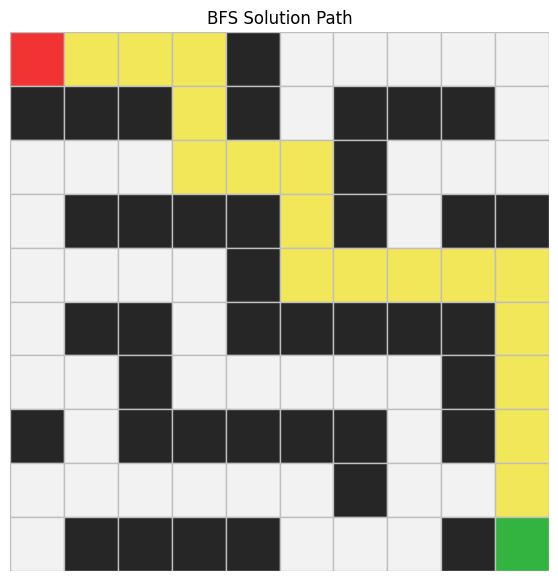

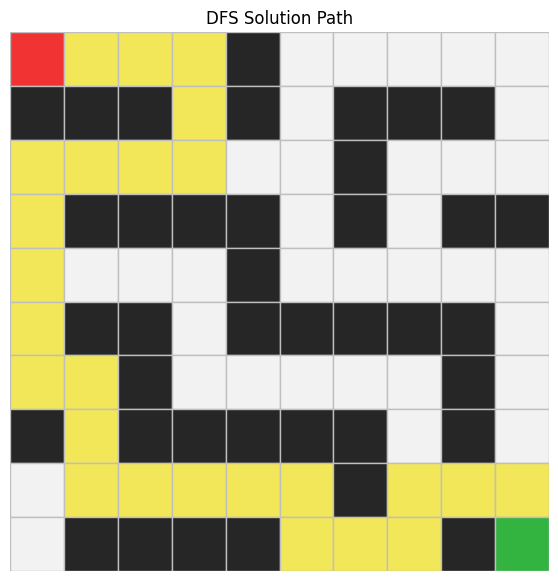

In [63]:
# Run the Algorithms on the Sample Map
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)
# Visualise solution paths.
# After your algorithms work, choose at least two algorithms and plot their paths.

bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)


---MAP 1 METRICS: THE DFS TRAP ---


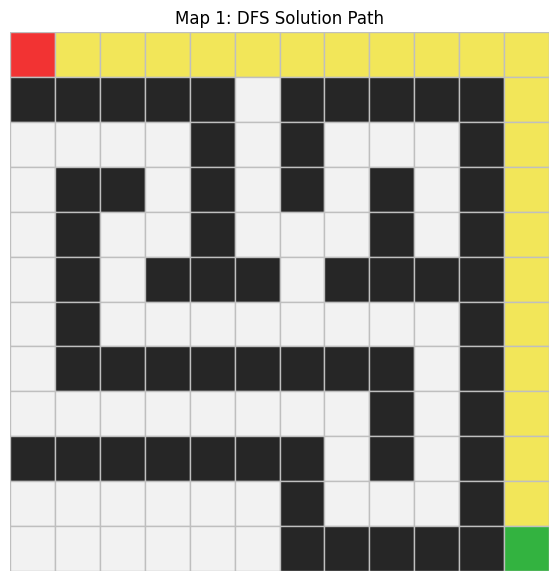

In [64]:
# Create Your Own Maps

#first map ( DFS trap room)
#A map with a long narrow corridor.
custom_grid_1 = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0],
    [0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0],
    [1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0]
]

# top - left, bottom - right
custom_start_1 = (0, 0)
custom_goal_1 = (11, 11)

#
custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=25),
    ids.search(custom_problem_1, max_depth=40),
]

# show _results(custom_results_1)
print("---MAP 1 METRICS: THE DFS TRAP ---")
show_results(custom_results_1)

plot_path(custom_grid_1, custom_start_1, custom_goal_1, path=custom_results_1[1].path, title="Map 1: DFS Solution Path")



--- METRICS FOR MAP 2: THE LARGE MAZE ---


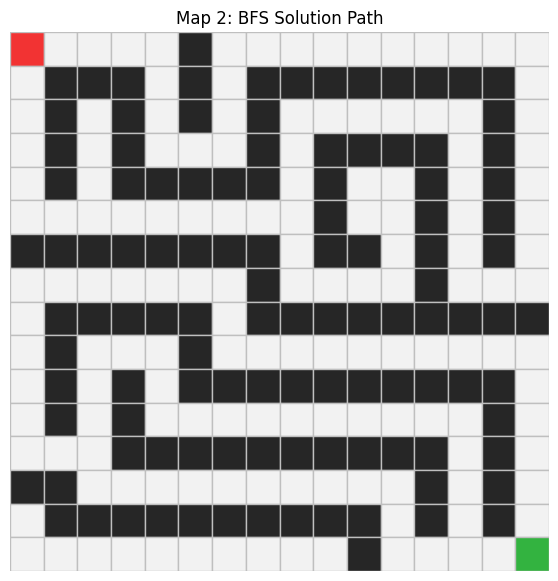

In [65]:
# TODO 11: Second Custom Map (Large Dual-Corridor)
custom_grid_2 = [
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0],
    [0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0],
    [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
]

custom_start_2 = (0, 0)
custom_goal_2 = (15, 15)

custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=35),
    ids.search(custom_problem_2, max_depth=60),
]

print("--- METRICS FOR MAP 2: THE LARGE MAZE ---")
show_results(custom_results_2)

# Visualize how your algorithms performed
plot_path(custom_grid_2, custom_start_2, custom_goal_2, path=custom_results_2[0].path, title="Map 2: BFS Solution Path")

In [66]:
#15. Reflection Questions


#15.1 Problem Formulation

#1. What is a state in this lab?
''' state is a coordinate tuple, (row, col)representing the exact cell location of the drone on the grid matrix'''
#2. What is an action?
''' An action is a valid movement choice for the drone. In this lab, it corresponds to moving one step such up, donw, left, right.'''
#3. What does the result function do?
''' result function acts as the engine of the environment. It takes a current state s an action, and returns the resulting state s' without modifying the original state'''
#4. Why is it useful to separate the problem definition from the search algorithm?
''' result function, It allows you to use the exact same search algorithms (BFS, DFS, IDS) to solve entirely different problemswithout rewriting a single line of your search engine code. You only need to redefine the problem rules.'''

#15.2 BFS

#1. Why does BFS use a FIFO queue?
'''FIFO means, first-In fist-Out, ensure that nodes are explored strictly in the order they are discovered. This forces the algorithm to explore the graph level by level, completing an entire ring of depth before moving deeper.'''
#2. Why does BFS find the shortest path in terms of number of steps on the unweighted grid?
''' Because it explores uniformly outward from the starting point. since every step cost exactly same unit '''
#3. What role does the reached set play in BFS?
''' set keeps track o every cooordinate cell the drone has already seeen. this protect and prevent the drone from wasting the  memory '''

#15.3 DFS
#1. Why does DFS use a stack?
'''DFS use LIFO, last In first out, this is because it want to pririotize deep exploration. it plunges dep down a single path until it hits dead ends before backtracking.'''
#2. Is DFS guaranteed to find the shortest path? Explain.
''' NO, DFS in not optimal, it blindly follow the first path it finds that lead to the goal.'''
#3 Under what conditions can DFS use less memory than BFS?
''' DFS uses leaa moemory in deep, branching state space where a slotion exits down most branches and BFS, has to store entire horizontal frontier layer of nodes in memory, DFS needs only to store the single current path branch that is exlporing'''
#4. Under what conditions can DFS perform badly?
''' DFS perfomes poor;y when in enviroment with deeop dead ends, or inifinite loops, it will massive use it engery or massive amount of power exploring a massive blind alley to its absolute floor, before backtracking to find the simple solution'''

#15.4 DLS
#1. What happens when the depth limit is too small?
''' DLS will terminate ealry without ever finding the target, returning a status cutoff'''
#2. What is the meaning of "cutoff"?
''' cutoff, this mean algorithm hit it maximu allowed depth boundary and had to  stop searching down that line, leaving parts of the deeper ppath unexplored'''
#3. How is DLS different from ordinary DFS?
''' Ordinary DLS, will explore down a bracnh indefinetly  until a natural wall or dead ends while with DLS acts exactly has DFS , it forces th algorithms to stop and backtrack immediately.'''
#4. Why do we use path-cycle checking in DLS?
''' beacsuse does not utilize a global set to keep track of visites nodes across the whole maze, it must use path cycle cheking to ensure the rone doesn't get caught pacing back and fourth in small cycle'''

#15.5 IDS
#1. why does IDS repeat DLS with increasing limits?
'''IDS repeats to gain the benfits of BFS optimality without the memoerry penalty. this by increasing the limit, it systematiccally searches every shallow level comletely beore going deeper.'''
#2. Why can IDS be complete even though DLS with a small limit is not?
'''DLS, is imcomplete because bad limit can cut off the solution, IDS fixes by continously expanding limit bracket.as long as goal exits at some depth and branching factor is finite.'''
#3. Why does IDS use less memory than BFS?
''' this because it is core, IDS it clear it memory frontier after each iteration and onlt tracks a single linear path stack at time.'''
#4. What is the cost of repeatedly searching from the root?
''' IDS repeatedely regenerates and re-expands the upper layer of the tree every time the limit increases. the cost is minimal because the vast majority of nodes in branching tree always live in absolute lowest leaf layer.'''

' IDS repeatedely regenerates and re-expands the upper layer of the tree every time the limit increases. the cost is minimal because the vast majority of nodes in branching tree always live in absolute lowest leaf layer.'

#15. Reflection Questions


#15.1 Problem Formulation

#1. What is a state in this lab?
''' state is a coordinate tuple, (row, col)representing the exact cell location of the drone on the grid matrix'''
#2. What is an action?
''' An action is a valid movement choice for the drone. In this lab, it corresponds to moving one step such up, donw, left, right.'''
#3. What does the result function do?
''' result function acts as the engine of the environment. It takes a current state s an action, and returns the resulting state s' without modifying the original state'''
#4. Why is it useful to separate the problem definition from the search algorithm?
''' result function, It allows you to use the exact same search algorithms (BFS, DFS, IDS) to solve entirely different problemswithout rewriting a single line of your search engine code. You only need to redefine the problem rules.'''

#15.2 BFS

#1. Why does BFS use a FIFO queue?
'''FIFO means, first-In fist-Out, ensure that nodes are explored strictly in the order they are discovered. This forces the algorithm to explore the graph level by level, completing an entire ring of depth before moving deeper.'''
#2. Why does BFS find the shortest path in terms of number of steps on the unweighted grid?
''' Because it explores uniformly outward from the starting point. since every step cost exactly same unit '''
#3. What role does the reached set play in BFS?
''' set keeps track o every cooordinate cell the drone has already seeen. this protect and prevent the drone from wasting the  memory '''

#15.3 DFS
#1. Why does DFS use a stack?
'''DFS use LIFO, last In first out, this is because it want to pririotize deep exploration. it plunges dep down a single path until it hits dead ends before backtracking.'''
#2. Is DFS guaranteed to find the shortest path? Explain.
''' NO, DFS in not optimal, it blindly follow the first path it finds that lead to the goal.'''
#3 Under what conditions can DFS use less memory than BFS?
''' DFS uses leaa moemory in deep, branching state space where a slotion exits down most branches and BFS, has to store entire horizontal frontier layer of nodes in memory, DFS needs only to store the single current path branch that is exlporing'''
#4. Under what conditions can DFS perform badly?
''' DFS perfomes poor;y when in enviroment with deeop dead ends, or inifinite loops, it will massive use it engery or massive amount of power exploring a massive blind alley to its absolute floor, before backtracking to find the simple solution'''

#15.4 DLS
#1. What happens when the depth limit is too small?
''' DLS will terminate ealry without ever finding the target, returning a status cutoff'''
#2. What is the meaning of "cutoff"?
''' cutoff, this mean algorithm hit it maximu allowed depth boundary and had to  stop searching down that line, leaving parts of the deeper ppath unexplored'''
#3. How is DLS different from ordinary DFS?
''' Ordinary DLS, will explore down a bracnh indefinetly  until a natural wall or dead ends while with DLS acts exactly has DFS , it forces th algorithms to stop and backtrack immediately.'''
#4. Why do we use path-cycle checking in DLS?
''' beacsuse does not utilize a global set to keep track of visites nodes across the whole maze, it must use path cycle cheking to ensure the rone doesn't get caught pacing back and fourth in small cycle'''

#15.5 IDS
#1. why does IDS repeat DLS with increasing limits?
'''IDS repeats to gain the benfits of BFS optimality without the memoerry penalty. this by increasing the limit, it systematiccally searches every shallow level comletely beore going deeper.'''
#2. Why can IDS be complete even though DLS with a small limit is not?
'''DLS, is imcomplete because bad limit can cut off the solution, IDS fixes by continously expanding limit bracket.as long as goal exits at some depth and branching factor is finite.'''
#3. Why does IDS use less memory than BFS?
''' this because it is core, IDS it clear it memory frontier after each iteration and onlt tracks a single linear path stack at time.'''
#4. What is the cost of repeatedly searching from the root?
''' IDS repeatedely regenerates and re-expands the upper layer of the tree every time the limit increases. the cost is minimal because the vast majority of nodes in branching tree always live in absolute lowest leaf layer.'''